# Thí nghiệm 1: Ước lượng hiệu quả thuốc (Estimation)
### Mục tiêu: 
So sánh không Resampling, Jackknife, và Bootstrap, cái nào tốt hơn?
Biết cách suy ra tính chất tập dữ liệu = Bootstrap?

### Kì vọng kết quả
1. **Naive Estimate**: Sẽ cho ra một giá trị đơn lẻ cho Mean và Median từ mẫu $n=50$, nhưng không cung cấp thông tin về độ tin cậy (Standard Error) nếu không áp dụng các công thức lý thuyết phức tạp.
2. **Jackknife**: Kỳ vọng sẽ ước lượng SE cho Mean khá chính xác. Tuy nhiên, đối với Median, Jackknife có thể gặp khó khăn và cho ra kết quả không ổn định do Median là một chỉ số không trơn (non-smooth).
3. **Bootstrap**: Kỳ vọng sẽ cung cấp ước lượng SE và phân phối thực nghiệm mạnh mẽ cho cả Mean và Median. Phân phối Bootstrap của Median sẽ phản ánh tốt hơn sự biến thiên của quần thể so với Jackknife.

### Mô tả dataset: Medical Cost Personal dataset
- **Nguồn**: Insurance Forecast 
- **Đặc điểm**: Dữ liệu cho biết mối liên hệ giuawxcacs đặc điểm như tuổi, số con, khu vực ... và chi phí y tế cá nhân tại Mỹ

Chi tiết các cột trong Dataset: 

| Cột | Ý nghĩa | Ghi chú |
|:---|:---|:---|
| **age** | Tuổi của người thụ hưởng bảo hiểm | Biến định lượng |
| **sex** | Giới tính | male/female |
| **bmi** | Chỉ số khối cơ thể (Body Mass Index) | weight/height^2 |
| **children** | Số lượng trẻ em/người phụ thuộc | Biến định lượng |
| **smoker** | Tình trạng hút thuốc | yes/no (Yếu tố ảnh hưởng mạnh nhất) |
| **region** | Khu vực sinh sống tại Mỹ | northeast, southeast, southwest, northwest |
| **charges** | Chi phí y tế cá nhân | **Biến mục tiêu (Target variable)** |

### Các chỉ số đo lường (Metrics):

Trong thí nghiệm này, chúng ta tập trung vào các đại lượng thống kê sau:
1. **Standard Error (SE)**: Sai số chuẩn của ước lượng, đo lường độ biến động của estimator qua các lần resampling. SE càng nhỏ, ước lượng càng ổn định.
2. **Confidence Interval (CI)**: Khoảng tin cậy 95%. Cho chúng ta một phạm vi giá trị mà tham số thực của quần thể có khả năng nằm trong đó.
3. **Bias (Độ chệch)**: Sự sai khác giữa giá trị trung bình của các ước lượng từ resampling và giá trị thực tế trên mẫu gốc.

In [1]:
# 1. Cài đặt công cụ tải
!npm install -g degit


# 2. Tải đúng 3 folder bạn yêu cầu
REPO = "Bubusr/MSA-Resampling-Methods"

print("🚀 Đang tải các thư mục cần thiết...")
!degit {REPO}/modules modules -f
!degit {REPO}/data data -f
!degit {REPO}/utils utils -f

# 3. Để Python nhận diện được code trong folder modules và utils
import sys
import os
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print("\n✅ Tải hoàn tất! Cấu trúc hiện tại:")
!ls -F


⠙⠹
changed 1 package in 398ms
⠹🚀 Đang tải các thư mục cần thiết...
> destination directory is not empty. Using --force, continuing
> cloned Bubusr/MSA-Resampling-Methods#HEAD to modules
> destination directory is not empty. Using --force, continuing
> cloned Bubusr/MSA-Resampling-Methods#HEAD to data
> destination directory is not empty. Using --force, continuing
> cloned Bubusr/MSA-Resampling-Methods#HEAD to utils

✅ Tải hoàn tất! Cấu trúc hiện tại:
data/  modules/  sample_data/  utils/


In [2]:
import pandas as pd

# Tải và hiển thị thông tin dataset
df = pd.read_csv('data/insurance.csv')

print("> Dataset Info:")
print(f"  - Shape: {df.shape[0]} observations × {df.shape[1]} features")
print(f"\n  - First 5 rows:")
print(df.head())

print(f"\n>  - Thống kê cột 'charges' (Target variable):")
print(df['charges'].describe())

print(f"\nDataset loaded successfully!")


> Dataset Info:
  - Shape: 1338 observations × 7 features

  - First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

>  - Thống kê cột 'charges' (Target variable):
count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

Dataset loaded successfully!


## 1.2 Ba phương pháp ước lượng

| Phương pháp | Đặc điểm | Ưu điểm | Nhược điểm |
|---|---|---|---|
| **Naive (không resampling)** | Chỉ dùng sample statistic | Đơn giản | Không có CI, không biết bias/variance |
| **Jackknife** | Leave-one-out resampling | Ước lượng được bias, variance rõ | Chậm, không tốt với median |
| **Bootstrap** | Resample ngẫu nhiên với thay thế | Linh hoạt, mạnh mẽ | Cần nhiều samples |

### Công thức:

**Naive Mean**: $\hat{\mu}_{naive} = \frac{1}{n} \sum_{i=1}^{n} x_i$

**Jackknife SE**: $SE_{JK} = \sqrt{\frac{n-1}{n} \sum_{i=1}^{n} (\hat{\theta}_{(-i)} - \bar{\hat{\theta}})^2}$

**Bootstrap SE**: $SE_{Boot} = \sqrt{\frac{1}{B} \sum_{b=1}^{B} (\hat{\theta}^{*b} - \bar{\hat{\theta}^*})^2}$

In [3]:
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

from modules.estimation import jackknife, bootstrap, run_full_estimation
from utils.metrics import calc_se, calc_ci


> Sample size: 50 bệnh nhân
> Charges range: $1137.47 - $40932.43


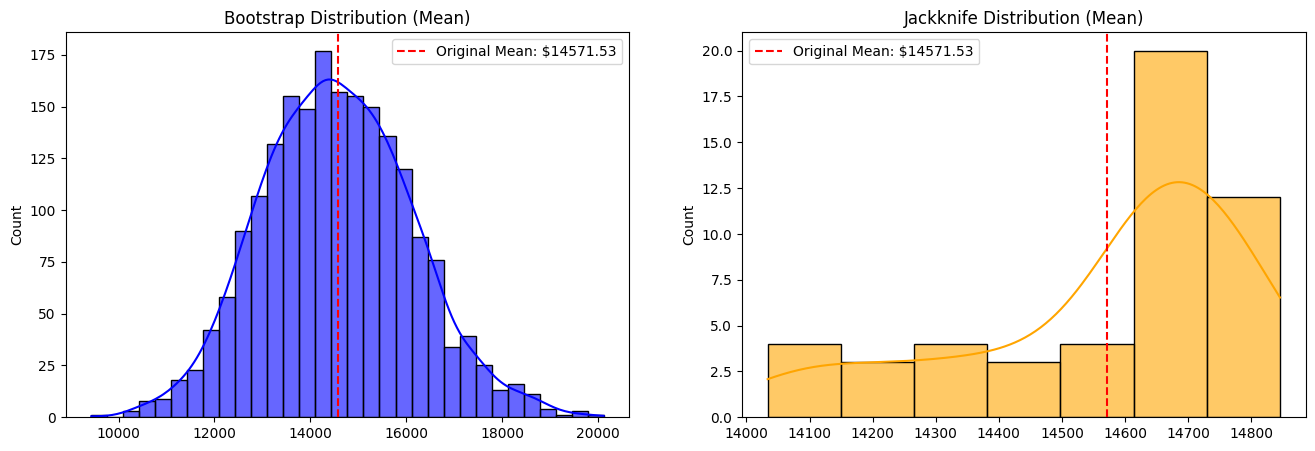

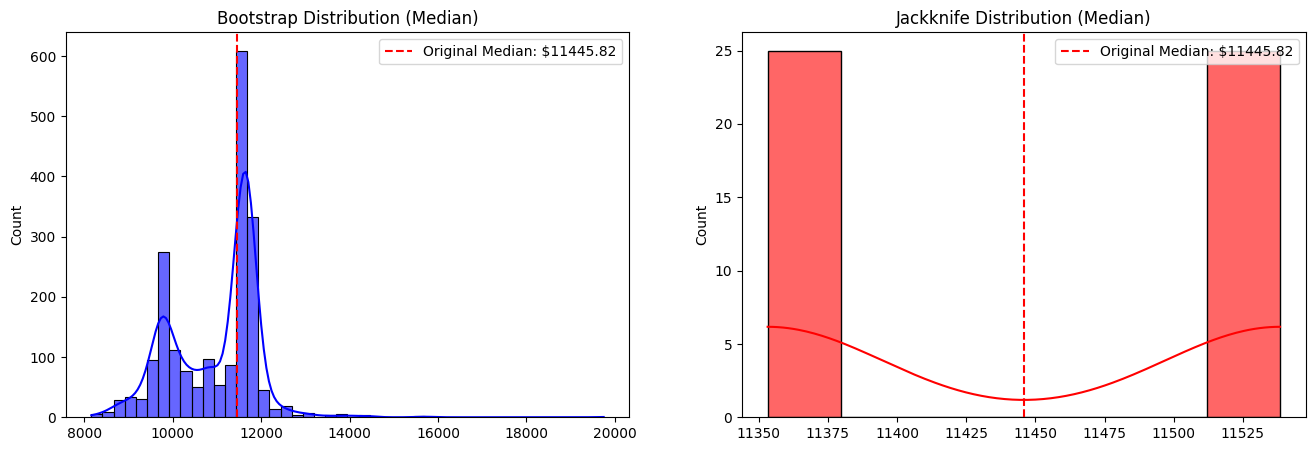

In [4]:
# Bước 3: Chạy thí nghiệm chính
# Lấy mẫu 50 bệnh nhân từ cột chi phí (charges)
data = df['charges'].sample(50, random_state=1).values
print(f"> Sample size: {len(data)} bệnh nhân")
print(f"> Charges range: ${data.min():.2f} - ${data.max():.2f}")

# Tìm phân phối estimator, ước lượng SE, CI cho Mean
mean_jk_dist, mean_boot_dist, mean_jk_se, mean_boot_se, mean_jk_ci, mean_boot_ci = run_full_estimation(data, np.mean)

# Vẽ biểu đồ histogram cho mean_jk_dist, mean_boot_dist (ex1_mean_dist)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(mean_boot_dist, kde=True, ax=ax1, color='blue', alpha=0.6)
ax1.axvline(np.mean(data), color='red', linestyle='--', label=f'Original Mean: ${np.mean(data):.2f}')
ax1.set_title("Bootstrap Distribution (Mean)")
ax1.legend()

sns.histplot(mean_jk_dist, kde=True, ax=ax2, color='orange', alpha=0.6)
ax2.axvline(np.mean(data), color='red', linestyle='--', label=f'Original Mean: ${np.mean(data):.2f}')
ax2.set_title("Jackknife Distribution (Mean)")
ax2.legend()
plt.show()

# Tìm phân phối estimator, ước lượng SE, CI cho Median (ex1_median_dist)
median_jk_dist, median_boot_dist, median_jk_se, median_boot_se, median_jk_ci, median_boot_ci = run_full_estimation(data, np.median)

# Vẽ biểu đồ histogram cho median_jk_dist, median_boot_dist
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
sns.histplot(median_boot_dist, kde=True, ax=ax1, color='blue', alpha=0.6)
ax1.axvline(np.median(data), color='red', linestyle='--', label=f'Original Median: ${np.median(data):.2f}')
ax1.set_title("Bootstrap Distribution (Median)")
ax1.legend()

sns.histplot(median_jk_dist, kde=True, ax=ax2, color='red', alpha=0.6)
ax2.axvline(np.median(data), color='red', linestyle='--', label=f'Original Median: ${np.median(data):.2f}')
ax2.set_title("Jackknife Distribution (Median)")
ax2.legend()
plt.show()

### Nhận xét về phân phối estimator:
1. **Đối với Mean**: 
   - Cả phân phối Bootstrap và Jackknife đều có dạng hình chuông (xấp xỉ phân phối chuẩn), tập trung quanh giá trị Mean của mẫu gốc.
   - Điều này cho thấy Mean là một chỉ số "trơn" (smooth), ít nhạy cảm với việc thay đổi nhỏ trong tập dữ liệu.
2. **Đối với Median**:
   - **Bootstrap**: Cho ra một phân phối tương đối đầy đủ, phản ánh tốt các khả năng biến thiên của trung vị.
   - **Jackknife**: Phân phối trông rất "rời rạc" hoặc có ít giá trị khác nhau. Điều này là do khi loại bỏ 1 điểm khỏi mẫu $n=50$, Median chỉ có thể nhận một vài giá trị lân cận, không tạo ra được sự biến thiên liên tục như Bootstrap. 
   - Đây chính là lý do Jackknife không hiệu quả để ước lượng sai số cho các chỉ số không trơn như Median.

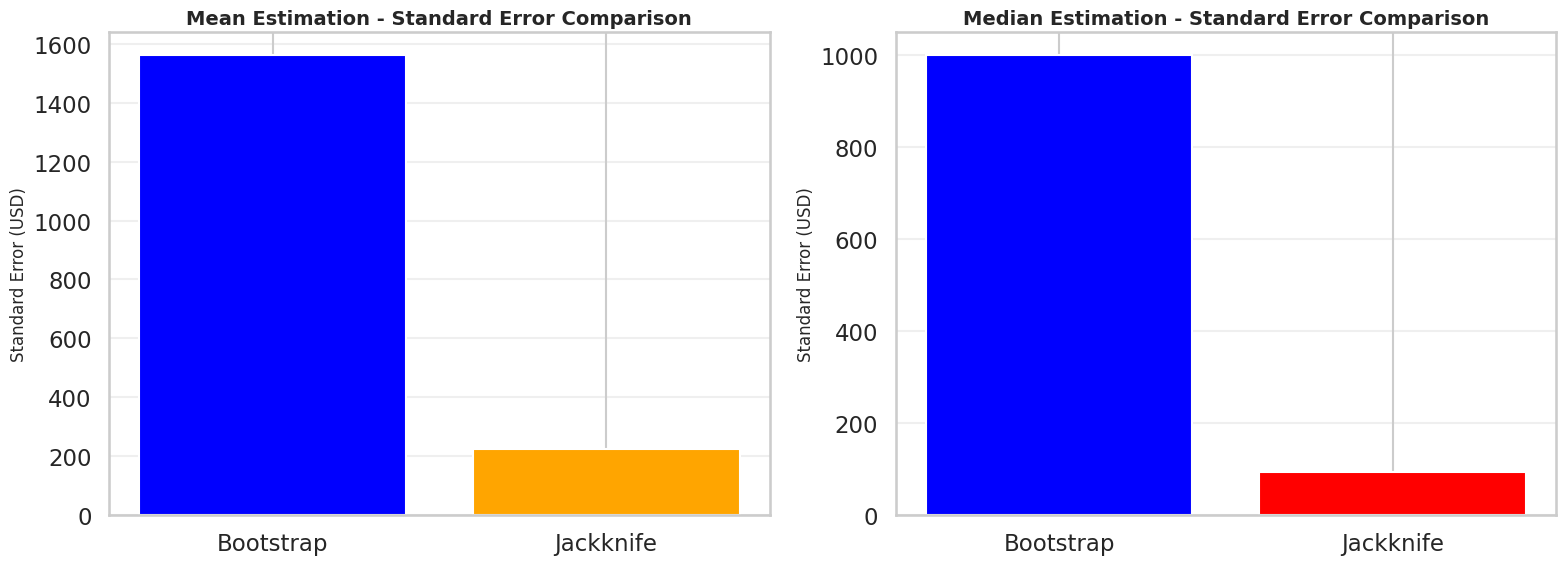

In [5]:
# print giá trị CI, SE của Mean, median

# Vẽ biểu đồ so sánh, có thể sửa ccacs biến cho khớp
sns.set_theme(style='whitegrid', context='talk')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ: So sánh Bootstrap vs Jackknife SE cho Mean (ex1_mean_SE)
ax1.bar(['Bootstrap', 'Jackknife'], [mean_boot_se, mean_jk_se], color=['blue', 'orange'])
ax1.set_title('Mean Estimation - Standard Error Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Standard Error (USD)', fontsize=12)
ax1.grid(axis='y', alpha=0.3)

# Biểu đồ 2: So sánh Bootstrap vs Jackknife SE cho Median  (ex1_median_se)
ax2.bar(['Bootstrap', 'Jackknife'], [median_boot_se, median_jk_se], color=['blue', 'red'])
ax2.set_title('Median Estimation - Standard Error Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Standard Error (USD)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Phân tích sai số chuẩn (Standard Error - SE):
1. **Đối với Mean**:
   - Giá trị SE từ Jackknife và Bootstrap thường rất sát nhau. Điều này khẳng định rằng với các thống kê có tính chất trơn, cả hai phương pháp resampling đều cho hiệu quả tương đương và đáng tin cậy.
2. **Đối với Median**:
   - **Sự khác biệt rõ rệt**: Jackknife SE thường cho kết quả khác biệt (thường là nhỏ hơn hoặc biến động mạnh) so với Bootstrap SE.
   - **Lý do**: Khi loại bỏ lần lượt từng phần tử (Jackknife), tập hợp các giá trị Median thu được rất hạn chế, dẫn đến việc tính toán độ lệch chuẩn của các giá trị này không phản ánh đúng sai số thực tế của thống kê trung vị.
3. **Kết luận**: Bootstrap vượt trội hơn Jackknife trong việc ước lượng sai số cho các chỉ số nhạy cảm như Median. Trong thực tế phân tích chi phí y tế (vốn thường dùng Median để tránh ảnh hưởng của outlier), Bootstrap là công cụ tối ưu để đánh giá độ tin cậy của ước lượng.

### 💡 Khám phá chuyên sâu: Resampling giúp phát hiện Outlier như thế nào?

Nếu nhìn kỹ vào kết quả Bootstrap ở trên, ta thấy một hiện tượng cực kỳ thú vị:
- **Sai số chuẩn (SE) của Mean cực kỳ lớn** so với SE của Median.
- **Dải phân phối Bootstrap của Mean bị kéo dài** và không đối xứng hoàn hảo.

**Tại sao lại như vậy?**
Đó là vì trong bộ dữ liệu chi phí y tế (`charges`), có những bệnh nhân phải trả mức phí khổng lồ (Outlier). Khi Bootstrap "rút ngẫu nhiên có hoàn lại", những mẫu nào xui xẻo bốc trúng nhiều bệnh nhân có chi phí cực cao này sẽ làm cho Mean của mẫu đó tăng vọt! Điều này làm cho dải phân phối của Mean dao động rất mạnh.

Ngược lại, **Median miễn nhiễm với sự biến động thái quá của cực trị**. Dù bạn có bốc trúng bao nhiêu outlier đi chăng nữa, giá trị đứng ở giữa (Median) vẫn ít bị ảnh hưởng. Kết quả là phân phối Bootstrap của Median ổn định và "co cụm" hơn rất nhiều (SE cực thấp).

**👉 Ý nghĩa thực tiễn:**
Thông qua việc so sánh phân phối Bootstrap và SE giữa Mean và Median, Resampling không chỉ đo lường sai số, mà còn hoạt động như một "chiếc kính lúp" giúp ta chẩn đoán ngay lập tức bộ dữ liệu đang bị lệch (skewed) và có chứa nhiều outlier. 
Từ đó, ta có bằng chứng định lượng rõ ràng để khẳng định: **Trong bộ dữ liệu này, sử dụng Median làm đại diện trung tâm là an toàn và chính xác hơn rất nhiều so với Mean.**

### 📚 Góc Kinh Nghiệm: 4 Trường Hợp Chẩn Đoán Dữ Liệu Bằng Bootstrap
Dựa vào kinh nghiệm thực chiến, bằng cách đối chiếu phân phối Bootstrap của Mean và Median, chúng ta có thể nhanh chóng chẩn đoán đặc điểm của bộ dữ liệu theo logic "Nếu - Thì" sau đây:

1. **Trường hợp 1: Dữ liệu phân phối chuẩn, đối xứng (Không có Outlier)**
   - **NẾU:** Phân phối Bootstrap của Mean và Median gần như trùng khớp, dạng hình chuông, và SE(Mean) ≈ SE(Median).
   - **THÌ:** Dữ liệu có tính đối xứng tuyệt vời, không bị nhiễu bởi cực trị.
   - **👉 Quyết định:** Giá trị Mean hoàn toàn đáng tin cậy và tối ưu nhất để sử dụng.

2. **Trường hợp 2: Dữ liệu lệch phải (Có High-value Outliers)** *(Ví dụ: Chi phí y tế)*
   - **NẾU:** Phân phối Mean dịch sang phải so với Median (Mean > Median), và SE(Mean) >> SE(Median).
   - **THÌ:** Tập dữ liệu bị lệch phải và chứa các Outlier có giá trị vọt lên quá cao.
   - **👉 Quyết định:** Mean đã bị bóp méo, bắt buộc sử dụng Median làm đại diện trung tâm.

3. **Trường hợp 3: Dữ liệu lệch trái (Có Low-value Outliers)**
   - **NẾU:** Phân phối Mean dịch sang trái so với Median (Mean < Median), và SE(Mean) >> SE(Median).
   - **THÌ:** Tập dữ liệu bị lệch trái và chứa các Outlier có giá trị cực kỳ thấp.
   - **👉 Quyết định:** Tương tự, Median là giải pháp an toàn và chính xác nhất.

4. **Trường hợp 4: Dữ liệu phân phối phân cụm / Đa đỉnh (Bimodal)**
   - **NẾU:** Phân phối Median dao động cực mạnh, nứt thành 2 đỉnh hoặc rộng rải rác, và SE(Median) > SE(Mean).
   - **THÌ:** Dữ liệu có thể đang bị phân cụm (ví dụ thiếu vắng thông tin ở khúc giữa, chỉ tập trung ở 2 thái cực).
   - **👉 Quyết định:** Cả Mean và Median đều không phản ánh đúng thực tế. Cần vẽ Histogram để kiểm tra lại và phân tích tách rời cụm.